
System: Lotka--Volterra
Group:  Polynomial
SINDy library: Polynomial
SORT basis: Legendre

--- Lotka--Volterra: sampling interval Δt = 0.1 ---
SINDy RMSE: 0.059122   status: ok
SORT  RMSE: 0.0478978   status: ok

--- Lotka--Volterra: sampling interval Δt = 0.25 ---
SINDy RMSE: 0.356774   status: ok
SORT  RMSE: 0.317257   status: ok

--- Lotka--Volterra: sampling interval Δt = 0.5 ---
SINDy RMSE: 1.64028   status: ok
SORT  RMSE: 1.99022   status: ok

--- Lotka--Volterra: sampling interval Δt = 0.75 ---
SINDy RMSE: 2.42024   status: ok
SORT  RMSE: 2.04443   status: ok

--- Lotka--Volterra: sampling interval Δt = 1.0 ---
SINDy RMSE: 953.844   status: ok
SORT  RMSE: 1.62758   status: ok

--- Lotka--Volterra: sampling interval Δt = 1.5 ---
SINDy RMSE: 947.006   status: ok
SORT  RMSE: 2.81653   status: ok

System: Van der Pol
Group:  Polynomial
SINDy library: Polynomial
SORT basis: Legendre

--- Van der Pol: sampling interval Δt = 0.1 ---
SINDy RMSE: 0.553735   status: ok
SORT  RMSE: 0.5538

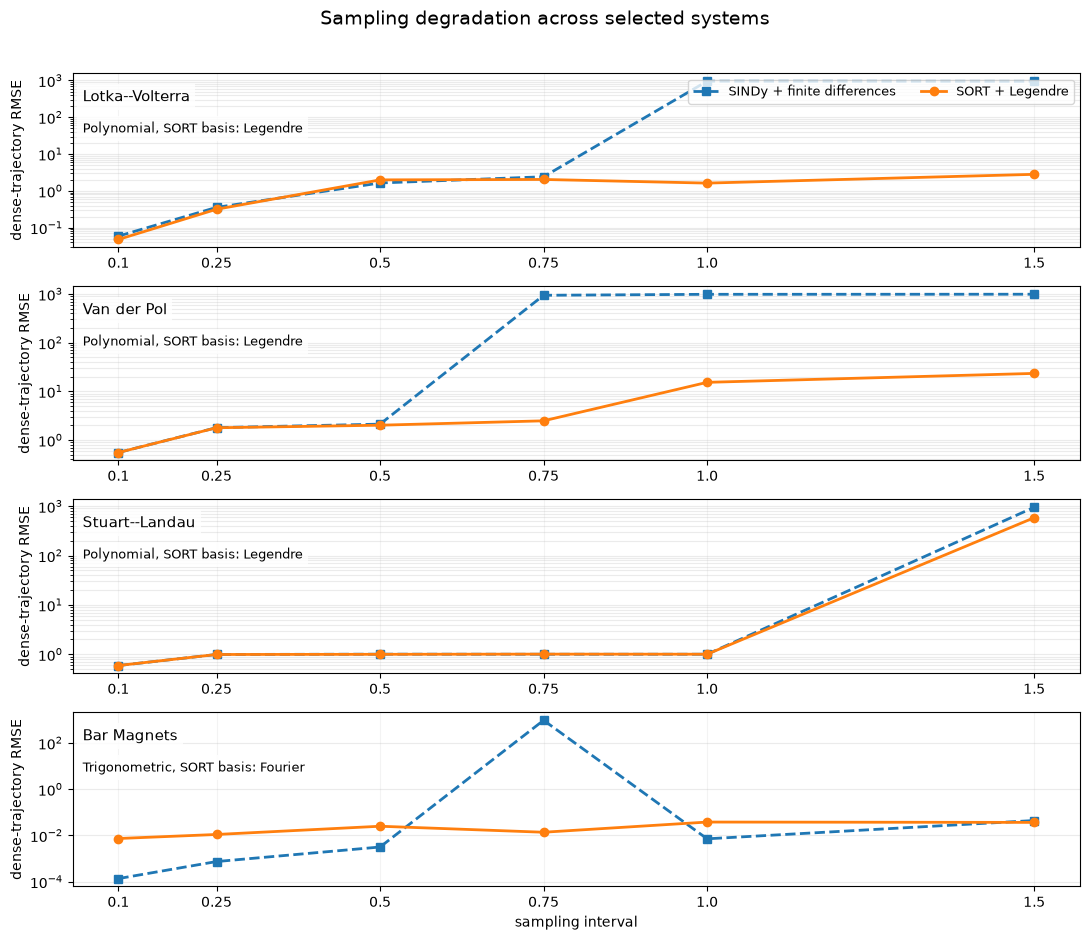

saved: selected_systems_sampling_degradation_rmse_stacked


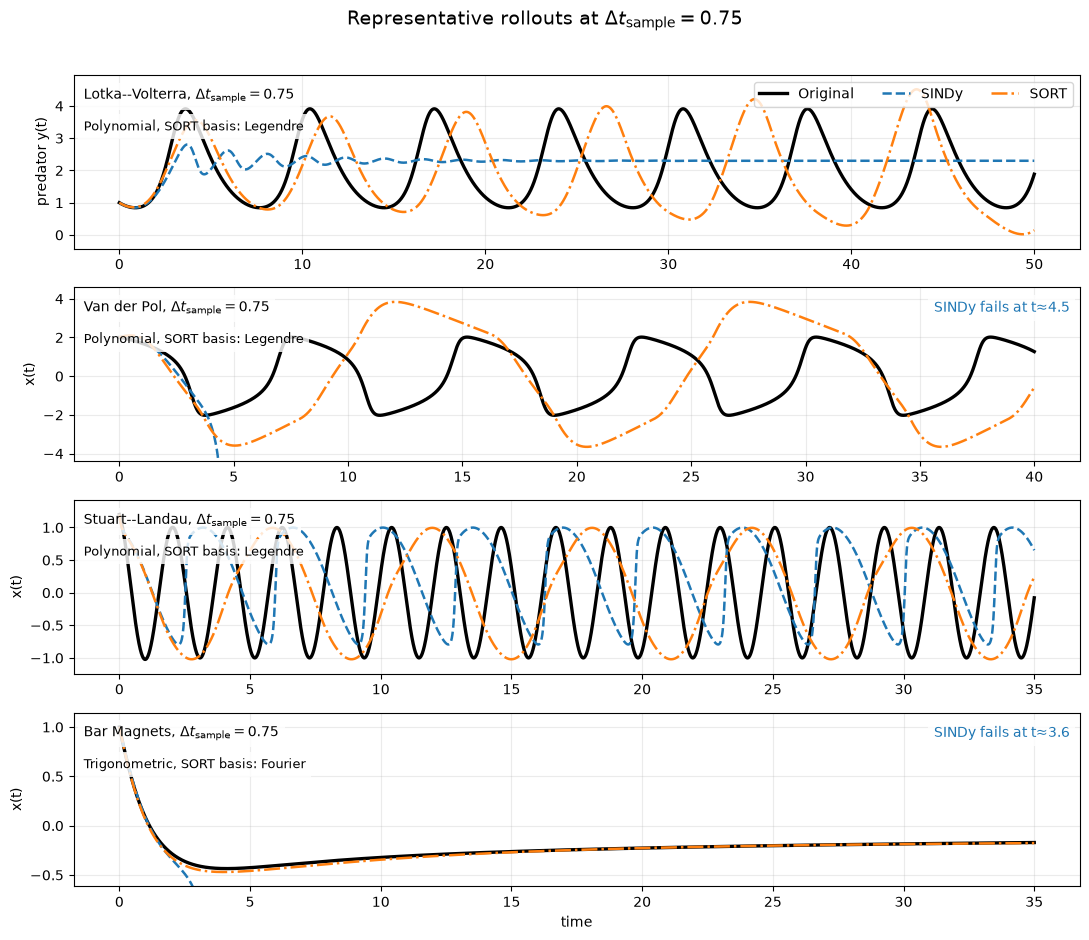

saved: selected_systems_dt_1p0_stacked_timeseries

Summary
-------
                  system |          group |    SINDy lib |   SORT basis |     dt |   SINDy RMSE |    SORT RMSE | SINDy fail t |  SORT fail t
----------------------------------------------------------------------------------------------------------------------------------
         Lotka--Volterra |     Polynomial |   Polynomial |     Legendre |    0.1 |     0.059122 |     0.047898 |         none |         none
         Lotka--Volterra |     Polynomial |   Polynomial |     Legendre |   0.25 |      0.35677 |      0.31726 |         none |         none
         Lotka--Volterra |     Polynomial |   Polynomial |     Legendre |    0.5 |       1.6403 |       1.9902 |         none |         none
         Lotka--Volterra |     Polynomial |   Polynomial |     Legendre |   0.75 |       2.4202 |       2.0444 |         none |         none
         Lotka--Volterra |     Polynomial |   Polynomial |     Legendre |    1.0 |       953.84 |

In [5]:
# ============================================================
# Four-system sampling-degradation experiment
# ============================================================
#
# Systems:
#   Polynomial / Legendre SORT:
#       1. Lotka--Volterra
#       2. Van der Pol
#       3. Stuart--Landau
#
#   Trigonometric / Fourier SORT:
#       4. Bar Magnets
#
# Outputs:
#   1. Stacked RMSE-vs-sampling figure, one row per system.
#   2. Stacked rollout figure at sampling interval dt = 1.0,
#      one row per system.
#
# Notes:
#   - Both SINDy and SORT use the same sampled states and the same
#     finite-difference derivative estimates.
#   - Polynomial degree is matched:
#         SINDy polynomial degree = 3
#         SORT Legendre total degree = 3
#   - SORT basis by system type:
#         polynomial    -> normalized Legendre basis on [-1,1]
#         trigonometric -> normalized real Fourier basis
#   - No smoothing is used.
# ============================================================

import os
import warnings
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from sklearn.linear_model import LassoCV
from sklearn.exceptions import ConvergenceWarning


# ============================================================
# 1. Settings
# ============================================================

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

OUTDIR = "figs_selected_sampling_degradation"
os.makedirs(OUTDIR, exist_ok=True)

SAVE_PDF = True
SAVE_PNG = True
SHOW_FIGS = True

TRUE_COLOR = "black"
SINDY_COLOR = "tab:blue"
SORT_COLOR = "tab:orange"

SAMPLE_DTS = [1e-1, 2.5e-1, 5e-1, 0.75, 1.0, 1.5]
SAMPLE_LABELS = ["0.1", "0.25", "0.5", "0.75", "1.0", "1.5"]

# Representative rollout sampling interval.
STACKED_DT = 0.75

NOISE_STD = 0.0

# Shared degree/order settings
SINDY_POLY_DEGREE = 3
LEGENDRE_DEGREE = 3
FOURIER_MAX_FREQ = 6

# SINDy
SINDY_THRESHOLD = 0.04
SINDY_RIDGE = 1e-8

# SORT
LASSO_ALPHAS = np.logspace(-6, -2, 80)

# Safety for learned rollouts
ROLL_OUT_CAP = 1e6
RMSE_CAP = 1e3


# ============================================================
# 2. Dynamical systems
# ============================================================

def rhs_lotka_volterra(t, x):
    alpha = 1.20
    beta = 0.60
    delta = 0.30
    gamma = 0.80

    prey, pred = x
    return np.array([
        alpha * prey - beta * prey * pred,
        delta * prey * pred - gamma * pred
    ], dtype=float)


def rhs_van_der_pol(t, x):
    mu = 2.0
    u, v = x
    return np.array([
        v,
        -u - mu * (u**2 - 1.0) * v
    ], dtype=float)


def rhs_stuart_landau(t, x):
    a = 1.0
    omega = 3.0
    u, v = x
    r2 = u**2 + v**2
    return np.array([
        a * u - omega * v - u * r2,
        omega * u + a * v - v * r2
    ], dtype=float)


def rhs_bar_magnets(t, x):
    K = 0.5
    u, v = x
    return np.array([
        K * np.sin(u - v) - np.sin(u),
        K * np.sin(v - u) - np.sin(v)
    ], dtype=float)


@dataclass
class SystemSpec:
    key: str
    title: str
    group: str
    sort_basis: str
    sindy_library: str
    rhs: callable
    x0: np.ndarray
    t0: float
    t1: float
    dt_dense: float
    max_step: float
    sindy_degree: int
    sort_degree: int
    plot_component: int
    plot_ylabel: str


SYSTEMS = [
    SystemSpec(
        key="lotka_volterra",
        title="Lotka--Volterra",
        group="Polynomial",
        sort_basis="Legendre",
        sindy_library="Polynomial",
        rhs=rhs_lotka_volterra,
        x0=np.array([1.5, 1.0]),
        t0=0.0,
        t1=50.0,
        dt_dense=0.01,
        max_step=0.02,
        sindy_degree=SINDY_POLY_DEGREE,
        sort_degree=LEGENDRE_DEGREE,
        plot_component=1,
        plot_ylabel="predator y(t)",
    ),
    SystemSpec(
        key="van_der_pol",
        title="Van der Pol",
        group="Polynomial",
        sort_basis="Legendre",
        sindy_library="Polynomial",
        rhs=rhs_van_der_pol,
        x0=np.array([2.0, 0.0]),
        t0=0.0,
        t1=40.0,
        dt_dense=0.01,
        max_step=0.02,
        sindy_degree=SINDY_POLY_DEGREE,
        sort_degree=LEGENDRE_DEGREE,
        plot_component=0,
        plot_ylabel="x(t)",
    ),
    SystemSpec(
        key="stuart_landau",
        title="Stuart--Landau",
        group="Polynomial",
        sort_basis="Legendre",
        sindy_library="Polynomial",
        rhs=rhs_stuart_landau,
        x0=np.array([1.2, 0.2]),
        t0=0.0,
        t1=35.0,
        dt_dense=0.01,
        max_step=0.02,
        sindy_degree=SINDY_POLY_DEGREE,
        sort_degree=LEGENDRE_DEGREE,
        plot_component=0,
        plot_ylabel="x(t)",
    ),
    SystemSpec(
        key="bar_magnets",
        title="Bar Magnets",
        group="Trigonometric",
        sort_basis="Fourier",
        sindy_library="Fourier",
        rhs=rhs_bar_magnets,
        x0=np.array([1.0, 2.0]),
        t0=0.0,
        t1=35.0,
        dt_dense=0.01,
        max_step=0.02,
        sindy_degree=SINDY_POLY_DEGREE,
        sort_degree=FOURIER_MAX_FREQ,
        plot_component=0,
        plot_ylabel="x(t)",
    ),
]

SYSTEM_BY_KEY = {s.key: s for s in SYSTEMS}


# ============================================================
# 3. Utility functions
# ============================================================

def save_fig(fig, filename_base):
    if SAVE_PDF:
        fig.savefig(os.path.join(OUTDIR, f"{filename_base}.pdf"), bbox_inches="tight")
    if SAVE_PNG:
        fig.savefig(os.path.join(OUTDIR, f"{filename_base}.png"), dpi=300, bbox_inches="tight")

    if SHOW_FIGS:
        plt.show()
    else:
        plt.close(fig)

    print(f"saved: {filename_base}")


def simulate_true(spec, t_eval):
    sol = solve_ivp(
        spec.rhs,
        (float(t_eval[0]), float(t_eval[-1])),
        np.asarray(spec.x0, dtype=float),
        t_eval=np.asarray(t_eval, dtype=float),
        rtol=1e-10,
        atol=1e-12,
        max_step=spec.max_step,
    )
    if not sol.success:
        raise RuntimeError(f"{spec.title}: {sol.message}")
    return sol.y.T


def rk4_rollout_safe(rhs, x0, t_eval, cap=ROLL_OUT_CAP):
    t_eval = np.asarray(t_eval, dtype=float)
    X = np.full((len(t_eval), len(x0)), np.nan, dtype=float)
    X[0] = np.asarray(x0, dtype=float)

    for i in range(len(t_eval) - 1):
        t = t_eval[i]
        dt = t_eval[i + 1] - t_eval[i]
        x = X[i]

        if (not np.all(np.isfinite(x))) or np.max(np.abs(x)) > cap:
            break

        try:
            k1 = rhs(t, x)
            k2 = rhs(t + 0.5 * dt, x + 0.5 * dt * k1)
            k3 = rhs(t + 0.5 * dt, x + 0.5 * dt * k2)
            k4 = rhs(t + dt, x + dt * k3)
            x_next = x + dt * (k1 + 2*k2 + 2*k3 + k4) / 6.0
        except Exception:
            break

        if (not np.all(np.isfinite(x_next))) or np.max(np.abs(x_next)) > cap:
            break

        X[i + 1] = x_next

    return X


def finite_difference_derivative(t, X):
    t = np.asarray(t, dtype=float)
    X = np.asarray(X, dtype=float)

    if len(t) < 3:
        return np.gradient(X, t, axis=0, edge_order=1)

    return np.gradient(X, t, axis=0, edge_order=2)


def capped_rmse(Xhat, Xtrue, cap=RMSE_CAP):
    Xhat = np.asarray(Xhat, dtype=float)
    Xtrue = np.asarray(Xtrue, dtype=float)

    err = Xhat - Xtrue
    bad = ~np.isfinite(err)
    err[bad] = cap
    err = np.clip(err, -cap, cap)

    return float(np.sqrt(np.mean(err**2)))


def failure_time(Xhat, t_eval):
    Xhat = np.asarray(Xhat, dtype=float)
    good = np.all(np.isfinite(Xhat), axis=1)

    if np.all(good):
        return np.nan

    idx = np.argmax(~good)
    return float(t_eval[idx])


def finite_for_plot(Y):
    Y = np.asarray(Y, dtype=float).copy()
    Y[~np.isfinite(Y)] = np.nan
    return Y


def closest_result_for_dt(results, target_dt):
    dts = np.array([r["dt"] for r in results], dtype=float)
    idx = int(np.argmin(np.abs(dts - target_dt)))
    return results[idx]


def rollout_cap_from_true(X_true):
    return max(50.0, 20.0 * float(np.nanmax(np.abs(X_true))))


def basis_label(name):
    if name == "Legendre":
        return "Legendre"
    if name == "Fourier":
        return "Fourier"
    return str(name).replace("_", " ").title()


# ============================================================
# 4. Polynomial library for SINDy
# ============================================================

def monomial_powers(n_vars, degree):
    powers = []

    def rec(prefix, remaining_degree, dim_left):
        if dim_left == 1:
            powers.append(tuple(prefix + [remaining_degree]))
            return

        for k in range(remaining_degree + 1):
            rec(prefix + [k], remaining_degree - k, dim_left - 1)

    for total_degree in range(degree + 1):
        rec([], total_degree, n_vars)

    return powers


def build_poly_library(X, degree):
    X = np.asarray(X, dtype=float)
    n_samples, n_vars = X.shape
    powers = monomial_powers(n_vars, degree)

    Theta = np.ones((n_samples, len(powers)), dtype=float)

    for col, p in enumerate(powers):
        val = np.ones(n_samples, dtype=float)
        for j, exponent in enumerate(p):
            if exponent:
                val *= X[:, j] ** exponent
        Theta[:, col] = val

    return Theta, powers


def eval_poly_features(x, powers):
    x = np.asarray(x, dtype=float)
    phi = np.ones(len(powers), dtype=float)

    for col, p in enumerate(powers):
        val = 1.0
        for j, exponent in enumerate(p):
            if exponent:
                val *= x[j] ** exponent
        phi[col] = val

    return phi


# ============================================================
# 5. Legendre and Fourier bases
# ============================================================

class MinMaxScalerMinusOneOne:
    """
    Maps observed states to the canonical Legendre domain [-1,1].
    """
    def __init__(self, padding=0.05, eps=1e-12):
        self.padding = padding
        self.eps = eps
        self.xmin = None
        self.xmax = None

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        xmin = X.min(axis=0)
        xmax = X.max(axis=0)
        span = np.maximum(xmax - xmin, self.eps)

        self.xmin = xmin - self.padding * span
        self.xmax = xmax + self.padding * span
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        if X.ndim == 1:
            X = X[None, :]

        span = np.maximum(self.xmax - self.xmin, self.eps)
        return 2.0 * (X - self.xmin) / span - 1.0


def normalized_legendre_vander(z, degree):
    """
    Orthonormal Legendre functions on [-1,1]:

        psi_n(z) = sqrt((2n+1)/2) P_n(z).
    """
    z = np.asarray(z, dtype=float)
    V = np.polynomial.legendre.legvander(z, degree)
    n = np.arange(degree + 1)
    norms = np.sqrt((2.0 * n + 1.0) / 2.0)
    return V * norms[None, :]


def total_degree_indices(n_vars, degree):
    indices = []

    def rec(prefix, remaining_degree, dim_left):
        if dim_left == 1:
            indices.append(tuple(prefix + [remaining_degree]))
            return

        for k in range(remaining_degree + 1):
            rec(prefix + [k], remaining_degree - k, dim_left - 1)

    for total_degree in range(degree + 1):
        rec([], total_degree, n_vars)

    return indices


def build_legendre_state_library(Z, degree):
    Z = np.asarray(Z, dtype=float)
    Z = np.clip(Z, -1.0, 1.0)

    n_samples, n_vars = Z.shape
    indices = total_degree_indices(n_vars, degree)

    one_dim = [
        normalized_legendre_vander(Z[:, j], degree)
        for j in range(n_vars)
    ]

    Phi = np.ones((n_samples, len(indices)), dtype=float)

    for col, alpha in enumerate(indices):
        val = np.ones(n_samples, dtype=float)
        for j, deg_j in enumerate(alpha):
            val *= one_dim[j][:, deg_j]
        Phi[:, col] = val

    return Phi, indices


def eval_legendre_state_features(z, indices, degree):
    z = np.asarray(z, dtype=float)
    z = np.clip(z, -1.0, 1.0)

    one_dim = [
        normalized_legendre_vander(np.array([zj]), degree)[0]
        for zj in z
    ]

    phi = np.ones(len(indices), dtype=float)

    for col, alpha in enumerate(indices):
        val = 1.0
        for j, deg_j in enumerate(alpha):
            val *= one_dim[j][deg_j]
        phi[col] = val

    return phi


def fourier_frequency_vectors(n_vars, max_freq):
    """
    Frequency vectors k for real Fourier modes cos(k dot x), sin(k dot x).

    Uses total frequency |k_1| + ... + |k_d| <= max_freq.
    Keeps one representative from each +/- pair.
    """
    grids = np.meshgrid(
        *[np.arange(-max_freq, max_freq + 1) for _ in range(n_vars)],
        indexing="ij"
    )

    raw = np.stack([g.ravel() for g in grids], axis=1)

    vectors = []
    for k in raw:
        if np.all(k == 0):
            continue

        if np.sum(np.abs(k)) > max_freq:
            continue

        first_nonzero = k[np.nonzero(k)[0][0]]
        if first_nonzero < 0:
            continue

        vectors.append(tuple(int(v) for v in k))

    vectors = sorted(
        vectors,
        key=lambda p: (sum(abs(v) for v in p), max(abs(v) for v in p), p)
    )
    return vectors


def build_fourier_library(X, max_freq):
    """
    Normalized real multivariate Fourier basis on the d-dimensional torus.

    Constant:
        (2*pi)^(-d/2)

    Nonzero modes:
        sqrt(2) * (2*pi)^(-d/2) cos(k dot x),
        sqrt(2) * (2*pi)^(-d/2) sin(k dot x).
    """
    X = np.asarray(X, dtype=float)
    n_samples, n_vars = X.shape

    freqs = fourier_frequency_vectors(n_vars, max_freq)

    const_norm = (2.0 * np.pi) ** (-0.5 * n_vars)
    mode_norm = np.sqrt(2.0) * const_norm

    cols = [np.full(n_samples, const_norm, dtype=float)]

    for k in freqs:
        phase = X @ np.asarray(k, dtype=float)
        cols.append(mode_norm * np.cos(phase))
        cols.append(mode_norm * np.sin(phase))

    Phi = np.column_stack(cols)
    return Phi, freqs, n_vars


def eval_fourier_features(x, freqs, n_vars):
    x = np.asarray(x, dtype=float)

    const_norm = (2.0 * np.pi) ** (-0.5 * n_vars)
    mode_norm = np.sqrt(2.0) * const_norm

    vals = [const_norm]
    for k in freqs:
        phase = float(x @ np.asarray(k, dtype=float))
        vals.append(mode_norm * np.cos(phase))
        vals.append(mode_norm * np.sin(phase))

    return np.asarray(vals, dtype=float)


# ============================================================
# 6. SINDy-style sparse library model
# ============================================================

def build_sindy_library(X, spec):
    """
    Fixed SINDy-style library selected by system class.

    Polynomial systems:
        polynomial degree 3

    Trigonometric systems:
        polynomial degree 3 + fixed Fourier features up to frequency 3
    """
    X = np.asarray(X, dtype=float)

    Theta_poly, powers = build_poly_library(X, degree=spec.sindy_degree)

    if spec.sindy_library == "Polynomial":
        return {
            "Theta": Theta_poly,
            "powers": powers,
            "freqs": None,
            "n_vars_fourier": None,
            "mode": "Polynomial",
        }

    if spec.sindy_library == "Fourier":
        Theta_fourier, freqs, n_vars_fourier = build_fourier_library(
            X,
            max_freq=spec.sort_degree,
        )

        # Drop duplicate constant column from Fourier library.
        Theta = np.column_stack([Theta_poly, Theta_fourier[:, 1:]])

        return {
            "Theta": Theta,
            "powers": powers,
            "freqs": freqs,
            "n_vars_fourier": n_vars_fourier,
            "mode": "Fourier",
        }

    raise ValueError(f"Unknown SINDy library mode: {spec.sindy_library}")


def eval_sindy_features(x, lib):
    x = np.asarray(x, dtype=float)

    phi_poly = eval_poly_features(x, lib["powers"])

    if lib["mode"] == "Polynomial":
        return phi_poly

    if lib["mode"] == "Fourier":
        phi_fourier = eval_fourier_features(
            x,
            lib["freqs"],
            lib["n_vars_fourier"],
        )

        # Drop duplicate constant column from Fourier library.
        return np.concatenate([phi_poly, phi_fourier[1:]])

    raise ValueError(f"Unknown SINDy library mode: {lib['mode']}")


def ridge_solve(A, B, alpha=SINDY_RIDGE):
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    return np.linalg.solve(A.T @ A + alpha * np.eye(A.shape[1]), A.T @ B)


def stlsq(Theta, dXdt, threshold=SINDY_THRESHOLD, ridge_alpha=SINDY_RIDGE, max_iter=10):
    Theta = np.asarray(Theta, dtype=float)
    dXdt = np.asarray(dXdt, dtype=float)

    col_norms = np.linalg.norm(Theta, axis=0)
    col_norms[col_norms == 0] = 1.0
    Theta_n = Theta / col_norms

    Xi = ridge_solve(Theta_n, dXdt, ridge_alpha)

    for _ in range(max_iter):
        small = np.abs(Xi) < threshold
        Xi[small] = 0.0

        for j in range(dXdt.shape[1]):
            active = ~small[:, j]
            if np.sum(active) == 0:
                continue

            Xi[active, j] = ridge_solve(
                Theta_n[:, active],
                dXdt[:, j:j+1],
                ridge_alpha,
            ).ravel()

    return Xi / col_norms[:, None]


def fit_sindy_fd(X, dXdt, spec):
    lib = build_sindy_library(X, spec)
    Xi = stlsq(lib["Theta"], dXdt)

    def rhs(t, x):
        return eval_sindy_features(x, lib) @ Xi

    return {
        "rhs": rhs,
        "Xi": Xi,
        "library": lib,
    }


# ============================================================
# 7. SORT model
# ============================================================

def fit_sort_fd(X, dXdt, spec, alphas=LASSO_ALPHAS):
    X = np.asarray(X, dtype=float)
    dXdt = np.asarray(dXdt, dtype=float)

    scaler = None
    indices = None
    freqs = None
    n_vars_fourier = None

    if spec.sort_basis == "Legendre":
        scaler = MinMaxScalerMinusOneOne(padding=0.05).fit(X)
        Z = scaler.transform(X)
        Phi, indices = build_legendre_state_library(Z, degree=spec.sort_degree)

        def eval_phi(x):
            z = scaler.transform(np.asarray(x, dtype=float)[None, :])[0]
            return eval_legendre_state_features(z, indices, degree=spec.sort_degree)

    elif spec.sort_basis == "Fourier":
        Phi, freqs, n_vars_fourier = build_fourier_library(
            X,
            max_freq=spec.sort_degree,
        )

        def eval_phi(x):
            return eval_fourier_features(
                np.asarray(x, dtype=float),
                freqs,
                n_vars_fourier,
            )

    else:
        raise ValueError(f"Unknown SORT basis: {spec.sort_basis}")

    models = []
    for j in range(dXdt.shape[1]):
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=ConvergenceWarning)

            model = LassoCV(
                alphas=alphas,
                fit_intercept=True,
                cv=min(5, len(X)),
                max_iter=100000,
                tol=1e-8,
                random_state=RANDOM_SEED,
            )
            model.fit(Phi, dXdt[:, j])

        models.append(model)

    def rhs(t, x):
        phi = eval_phi(x)
        return np.array([m.predict(phi[None, :])[0] for m in models], dtype=float)

    return {
        "rhs": rhs,
        "models": models,
        "basis": spec.sort_basis,
        "scaler": scaler,
        "indices": indices,
        "freqs": freqs,
        "n_vars_fourier": n_vars_fourier,
    }


# ============================================================
# 8. Run sampling sweep for selected systems
# ============================================================

all_results = {}

for spec in SYSTEMS:
    print("\n" + "=" * 80)
    print(f"System: {spec.title}")
    print(f"Group:  {spec.group}")
    print(f"SINDy library: {spec.sindy_library}")
    print(f"SORT basis: {spec.sort_basis}")
    print("=" * 80)

    t_dense = np.arange(spec.t0, spec.t1 + 1e-12, spec.dt_dense)
    X_true = simulate_true(spec, t_dense)

    rollout_cap = rollout_cap_from_true(X_true)

    system_results = []

    for dt_obs, label in zip(SAMPLE_DTS, SAMPLE_LABELS):
        print(f"\n--- {spec.title}: sampling interval Δt = {label} ---")

        t_obs = np.arange(spec.t0, spec.t1 + 0.5 * dt_obs, dt_obs)

        X_obs_clean = np.column_stack([
            np.interp(t_obs, t_dense, X_true[:, j])
            for j in range(X_true.shape[1])
        ])

        X_obs = X_obs_clean + rng.normal(0.0, NOISE_STD, size=X_obs_clean.shape)
        dX_fd = finite_difference_derivative(t_obs, X_obs)

        try:
            sindy = fit_sindy_fd(X_obs, dX_fd, spec)
            X_sindy = rk4_rollout_safe(
                sindy["rhs"],
                X_obs_clean[0],
                t_dense,
                cap=rollout_cap,
            )
            sindy_status = "ok"
        except Exception as e:
            print("SINDy failed during fitting:", repr(e))
            sindy = None
            X_sindy = np.full_like(X_true, np.nan)
            sindy_status = "fit failed"

        try:
            sort = fit_sort_fd(X_obs, dX_fd, spec)
            X_sort = rk4_rollout_safe(
                sort["rhs"],
                X_obs_clean[0],
                t_dense,
                cap=rollout_cap,
            )
            sort_status = "ok"
        except Exception as e:
            print("SORT failed during fitting:", repr(e))
            sort = None
            X_sort = np.full_like(X_true, np.nan)
            sort_status = "fit failed"

        err_sindy = capped_rmse(X_sindy, X_true)
        err_sort = capped_rmse(X_sort, X_true)

        print(f"SINDy RMSE: {err_sindy:.6g}   status: {sindy_status}")
        print(f"SORT  RMSE: {err_sort:.6g}   status: {sort_status}")

        system_results.append({
            "dt": dt_obs,
            "label": label,
            "t_obs": t_obs,
            "X_obs": X_obs,
            "dX_fd": dX_fd,
            "sindy": sindy,
            "sort": sort,
            "X_sindy": X_sindy,
            "X_sort": X_sort,
            "rmse_sindy": err_sindy,
            "rmse_sort": err_sort,
            "fail_time_sindy": failure_time(X_sindy, t_dense),
            "fail_time_sort": failure_time(X_sort, t_dense),
            "rollout_cap": rollout_cap,
        })

    all_results[spec.key] = {
        "spec": spec,
        "t_dense": t_dense,
        "X_true": X_true,
        "results": system_results,
    }


# ============================================================
# 9. Plot stacked RMSE vs sampling interval
# ============================================================

n = len(SYSTEMS)

fig, axes = plt.subplots(
    n,
    1,
    figsize=(11.0, 2.35 * n),
    sharex=False,
)

if n == 1:
    axes = [axes]

for ax, spec in zip(axes, SYSTEMS):
    bundle = all_results[spec.key]
    results = bundle["results"]

    dt_vals = np.array([r["dt"] for r in results], dtype=float)
    rmse_sindy = np.array([r["rmse_sindy"] for r in results], dtype=float)
    rmse_sort = np.array([r["rmse_sort"] for r in results], dtype=float)

    ax.plot(
        dt_vals,
        np.maximum(rmse_sindy, 1e-12),
        color=SINDY_COLOR,
        marker="s",
        linewidth=2.0,
        linestyle="--",
        label="SINDy + finite differences",
    )

    ax.plot(
        dt_vals,
        np.maximum(rmse_sort, 1e-12),
        color=SORT_COLOR,
        marker="o",
        linewidth=2.0,
        linestyle="-",
        label=f"SORT + {basis_label(spec.sort_basis)}",
    )

    ax.set_yscale("log")
    ax.set_ylabel("dense-trajectory RMSE")
    ax.grid(True, axis="y", which="both", alpha=0.25)
    ax.grid(True, axis="x", which="major", alpha=0.15)
    ax.set_xticks(dt_vals)
    ax.set_xticklabels([r["label"] for r in results])

    ax.text(
        0.01,
        0.84,
        spec.title,
        transform=ax.transAxes,
        fontsize=11,
        bbox=dict(facecolor="white", alpha=0.84, edgecolor="none"),
    )

    ax.text(
        0.01,
        0.66,
        f"{spec.group}, SORT basis: {basis_label(spec.sort_basis)}",
        transform=ax.transAxes,
        fontsize=9,
        bbox=dict(facecolor="white", alpha=0.84, edgecolor="none"),
    )

axes[0].legend(loc="upper right", ncol=2, fontsize=9)
axes[-1].set_xlabel("sampling interval")

fig.suptitle(
    "Sampling degradation across selected systems",
    y=0.995,
    fontsize=14,
)

fig.tight_layout(rect=[0, 0, 1, 0.98])
save_fig(fig, "selected_systems_sampling_degradation_rmse_stacked")


# ============================================================
# 10. Plot stacked time series at STACKED_DT
# ============================================================

STACKED_SYSTEM_KEYS = [
    "lotka_volterra",
    "van_der_pol",
    "stuart_landau",
    "bar_magnets",
]

n = len(STACKED_SYSTEM_KEYS)

fig, axes = plt.subplots(
    n,
    1,
    figsize=(11.0, 2.35 * n),
    sharex=False,
)

if n == 1:
    axes = [axes]

for ax, key in zip(axes, STACKED_SYSTEM_KEYS):
    bundle = all_results[key]
    spec = bundle["spec"]
    t_dense = bundle["t_dense"]
    X_true = bundle["X_true"]
    r = closest_result_for_dt(bundle["results"], STACKED_DT)

    component = spec.plot_component

    vals = [X_true[:, component]]

    ys_sort = r["X_sort"][:, component]
    ys_sort = ys_sort[np.isfinite(ys_sort)]
    ys_sort = ys_sort[np.abs(ys_sort) < r["rollout_cap"]]
    if len(ys_sort):
        vals.append(ys_sort)

    vals = np.concatenate(vals)
    lo, hi = np.nanmin(vals), np.nanmax(vals)
    span = max(hi - lo, 1e-8)
    ylim = (lo - 0.10 * span, hi + 0.10 * span)

    ax.plot(
        t_dense,
        X_true[:, component],
        color=TRUE_COLOR,
        linewidth=2.4,
        label="Original",
    )

    ax.plot(
        t_dense,
        finite_for_plot(r["X_sindy"][:, component]),
        color=SINDY_COLOR,
        linewidth=1.8,
        linestyle="--",
        label="SINDy",
    )

    ax.plot(
        t_dense,
        finite_for_plot(r["X_sort"][:, component]),
        color=SORT_COLOR,
        linewidth=1.8,
        linestyle="-.",
        label="SORT",
    )

    ax.set_ylim(*ylim)
    ax.grid(alpha=0.25)
    ax.set_ylabel(spec.plot_ylabel)

    ax.text(
        0.01,
        0.86,
        f"{spec.title}, " + rf"$\Delta t_\mathrm{{sample}}={r['label']}$",
        transform=ax.transAxes,
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.82, edgecolor="none"),
    )

    ax.text(
        0.01,
        0.68,
        f"{spec.group}, SORT basis: {basis_label(spec.sort_basis)}",
        transform=ax.transAxes,
        fontsize=9,
        bbox=dict(facecolor="white", alpha=0.82, edgecolor="none"),
    )

    if np.isfinite(r["fail_time_sindy"]):
        ax.text(
            0.99,
            0.86,
            f"SINDy fails at t≈{r['fail_time_sindy']:.1f}",
            transform=ax.transAxes,
            ha="right",
            fontsize=10,
            color=SINDY_COLOR,
            bbox=dict(facecolor="white", alpha=0.82, edgecolor="none"),
        )

axes[0].legend(loc="upper right", ncol=3)
axes[-1].set_xlabel("time")

fig.suptitle(
    rf"Representative rollouts at $\Delta t_\mathrm{{sample}}={STACKED_DT}$",
    y=0.995,
    fontsize=14,
)

fig.tight_layout(rect=[0, 0, 1, 0.98])
save_fig(fig, "selected_systems_dt_1p0_stacked_timeseries")


# ============================================================
# 11. Print compact summary table
# ============================================================

print("\nSummary")
print("-------")
print(
    f"{'system':>24s} | {'group':>14s} | {'SINDy lib':>12s} | {'SORT basis':>12s} | {'dt':>6s} | "
    f"{'SINDy RMSE':>12s} | {'SORT RMSE':>12s} | "
    f"{'SINDy fail t':>12s} | {'SORT fail t':>12s}"
)
print("-" * 130)

for spec in SYSTEMS:
    for r in all_results[spec.key]["results"]:
        ft_sindy = "none" if not np.isfinite(r["fail_time_sindy"]) else f"{r['fail_time_sindy']:.2f}"
        ft_sort = "none" if not np.isfinite(r["fail_time_sort"]) else f"{r['fail_time_sort']:.2f}"

        print(
            f"{spec.title:>24s} | "
            f"{spec.group:>14s} | "
            f"{spec.sindy_library:>12s} | "
            f"{basis_label(spec.sort_basis):>12s} | "
            f"{r['label']:>6s} | "
            f"{r['rmse_sindy']:12.5g} | "
            f"{r['rmse_sort']:12.5g} | "
            f"{ft_sindy:>12s} | "
            f"{ft_sort:>12s}"
        )

print(f"\nAll figures saved in: {OUTDIR}")